# Notebook 3 — COVID-19 Impact via Interrupted Time Series
## Did the pandemic causally disrupt bail justice, and did courts recover?

**Interrupted Time Series (ITS)** is a quasi-experimental design — the strongest causal inference
possible without a randomised control group. It models:
1. The **level change** at the intervention (Mar 2020 lockdown)
2. The **slope change** in the post-intervention period

We model 4 outcomes monthly and then compare recovery rates across major courts.


In [1]:
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")

DATA_PATH = Path("Compiled Bail case data.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Cannot locate 'Compiled Bail case data.csv'. "
        "Place it next to this notebook."
    )
print(f"Data path: {DATA_PATH}")
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac


Data path: Compiled Bail case data.csv


## B. Monthly Aggregation

In [2]:
COLS = ["DATE_FILED", "DECISION_DATE", "CURRENT_STATUS",
        "DISPOSAL_DAYS...1", "NAME_OF_HIGH_COURT", "Mapped_Bail"]
raw = pd.read_csv(DATA_PATH, usecols=COLS, low_memory=False)

for col in ["DATE_FILED", "DECISION_DATE"]:
    ymd = pd.to_datetime(raw[col], format="%Y-%m-%d", errors="coerce")
    dmy = pd.to_datetime(raw[col], format="%d-%m-%Y", errors="coerce")
    raw[col] = ymd.fillna(dmy)

raw["DISPOSAL_DAYS"] = pd.to_numeric(raw["DISPOSAL_DAYS...1"], errors="coerce")
raw["filed_month"]   = raw["DATE_FILED"].dt.to_period("M")
raw["disposed_month"]= raw["DECISION_DATE"].dt.to_period("M")

# --- 1. Monthly filing volume
monthly_filings = (
    raw.dropna(subset=["filed_month"])
       .groupby("filed_month")
       .size()
       .rename("filings")
       .reset_index()
)
monthly_filings["filed_month"] = monthly_filings["filed_month"].dt.to_timestamp()
monthly_filings = monthly_filings[
    (monthly_filings["filed_month"] >= "2014-01-01") &
    (monthly_filings["filed_month"] <= "2021-12-31")
].sort_values("filed_month")

# --- 2. Monthly disposal volume
monthly_disposals = (
    raw.dropna(subset=["disposed_month"])
       .groupby("disposed_month")
       .size()
       .rename("disposals")
       .reset_index()
)
monthly_disposals["disposed_month"] = monthly_disposals["disposed_month"].dt.to_timestamp()
monthly_disposals = monthly_disposals[
    (monthly_disposals["disposed_month"] >= "2014-01-01") &
    (monthly_disposals["disposed_month"] <= "2021-12-31")
].sort_values("disposed_month")

# --- 3. Monthly median disposal days
monthly_disp_days = (
    raw[raw["CURRENT_STATUS"] == "Disposed"]
       .dropna(subset=["disposed_month", "DISPOSAL_DAYS"])
       .groupby("disposed_month")["DISPOSAL_DAYS"]
       .median()
       .reset_index()
)
monthly_disp_days["disposed_month"] = monthly_disp_days["disposed_month"].dt.to_timestamp()
monthly_disp_days = monthly_disp_days[
    (monthly_disp_days["disposed_month"] >= "2014-01-01") &
    (monthly_disp_days["disposed_month"] <= "2021-12-31")
].sort_values("disposed_month")

print(f"Monthly filings series: {len(monthly_filings)} months")
print(f"Monthly disposals series: {len(monthly_disposals)} months")
print(f"Monthly median disposal days: {len(monthly_disp_days)} months")


Monthly filings series: 96 months
Monthly disposals series: 96 months
Monthly median disposal days: 96 months


## C. ITS Model Setup
`lockdown` = step function (0 before Mar 2020, 1 after); `time_after` = running months since lockdown

In [3]:
LOCKDOWN_DATE = pd.Timestamp("2020-03-01")

def build_its_df(ts_df, date_col, value_col):
    """Build ITS regression dataframe from a monthly time series."""
    ts = ts_df.copy().rename(columns={date_col: "date", value_col: "Y"})
    ts = ts.sort_values("date").reset_index(drop=True)
    ts["t"]          = np.arange(1, len(ts) + 1)
    ts["lockdown"]   = (ts["date"] >= LOCKDOWN_DATE).astype(int)
    ts["time_after"] = ts.apply(
        lambda r: max(0, (r["date"].year - 2020) * 12 + r["date"].month - 3)
        if r["date"] >= LOCKDOWN_DATE else 0,
        axis=1
    )
    return ts

def fit_its(ts_df, outcome_label, color="#4C78A8"):
    """Fit segmented OLS with Newey-West HAC SEs and plot results."""
    X = sm.add_constant(ts_df[["t", "lockdown", "time_after"]])
    model = sm.OLS(ts_df["Y"], X).fit(
        cov_type="HAC", cov_kwds={"maxlags": 3}
    )

    # Counterfactual (no lockdown)
    cf_X = X.copy()
    cf_X["lockdown"]   = 0
    cf_X["time_after"] = 0
    counterfactual = model.predict(cf_X)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(ts_df["date"], ts_df["Y"], "o-", color=color, markersize=3, label="Observed", linewidth=1.5)
    ax.plot(ts_df["date"], model.fittedvalues, "-", color="black", linewidth=2, label="ITS fit")
    ax.plot(ts_df["date"], counterfactual, "--", color="gray", linewidth=1.5, label="Counterfactual")
    ax.axvline(LOCKDOWN_DATE, color="red", linestyle="--", linewidth=1, label="COVID lockdown (Mar 2020)")
    ax.fill_betweenx(
        [ax.get_ylim()[0], ax.get_ylim()[1]],
        LOCKDOWN_DATE, pd.Timestamp("2020-12-01"),
        alpha=0.08, color="red", label="Lockdown period"
    )
    ax.set_title(f"ITS: {outcome_label}")
    ax.set_xlabel("Month")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*50}")
    print(f"ITS Results — {outcome_label}")
    print(f"{'='*50}")
    print(f"  Pre-trend slope (t):          {model.params['t']:.3f}  (p={model.pvalues['t']:.4f})")
    print(f"  Level change at lockdown:     {model.params['lockdown']:.1f}  (p={model.pvalues['lockdown']:.4f})")
    print(f"  Slope change post-lockdown:   {model.params['time_after']:.3f}  (p={model.pvalues['time_after']:.4f})")
    print(f"  R²: {model.rsquared:.3f}")
    return model


## D. ITS Model 1 — Monthly Filing Volume

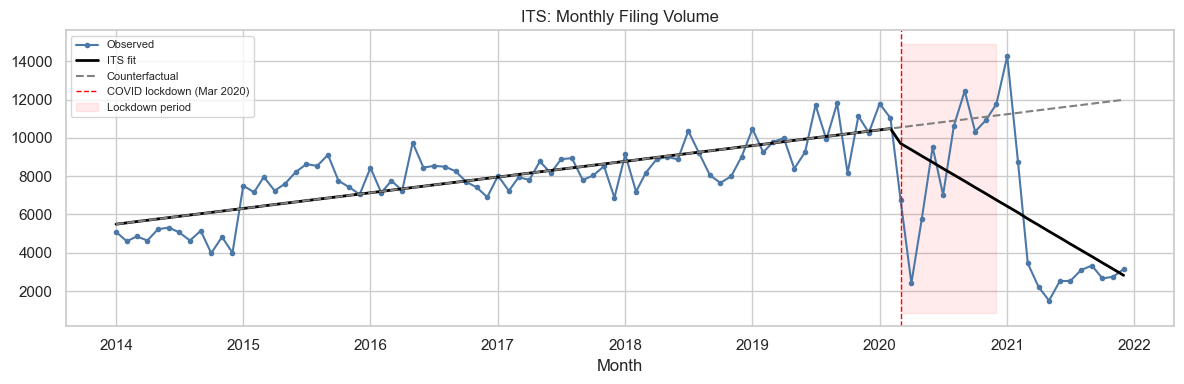


ITS Results — Monthly Filing Volume
  Pre-trend slope (t):          68.340  (p=0.0000)
  Level change at lockdown:     -845.3  (p=0.7234)
  Slope change post-lockdown:   -396.041  (p=0.0064)
  R²: 0.471


In [4]:
its_filings = build_its_df(monthly_filings, "filed_month", "filings")
model_filings = fit_its(its_filings, "Monthly Filing Volume", color="#4C78A8")


## E. ITS Model 2 — Monthly Disposal Volume

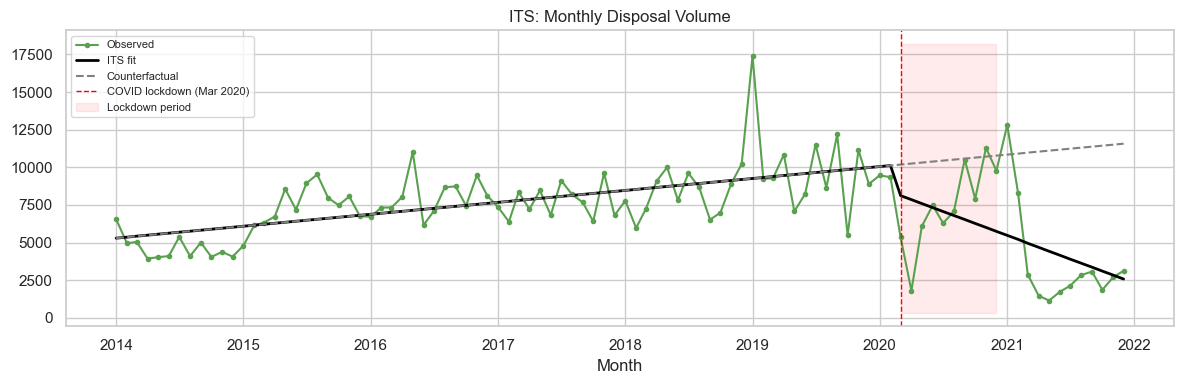


ITS Results — Monthly Disposal Volume
  Pre-trend slope (t):          66.085  (p=0.0000)
  Level change at lockdown:     -2065.8  (p=0.2980)
  Slope change post-lockdown:   -330.047  (p=0.0068)
  R²: 0.414


In [5]:
its_disposals = build_its_df(monthly_disposals, "disposed_month", "disposals")
model_disposals = fit_its(its_disposals, "Monthly Disposal Volume", color="#59A14F")


## F. ITS Model 3 — Monthly Median Disposal Days

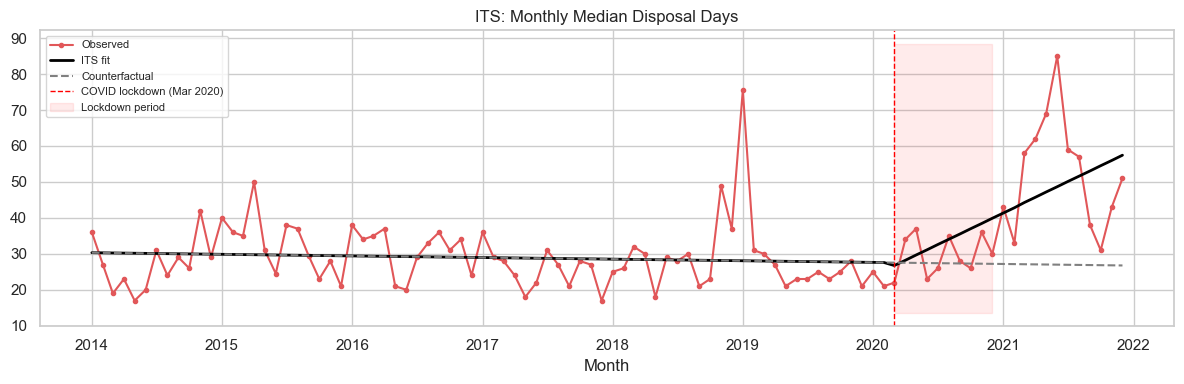


ITS Results — Monthly Median Disposal Days
  Pre-trend slope (t):          -0.037  (p=0.5865)
  Level change at lockdown:     -0.8  (p=0.8711)
  Slope change post-lockdown:   1.499  (p=0.0105)
  R²: 0.336


In [6]:
its_days = build_its_df(monthly_disp_days, "disposed_month", "DISPOSAL_DAYS")
model_days = fit_its(its_days, "Monthly Median Disposal Days", color="#E15759")


## G. Net Backlog Trajectory
(Cumulative filings − cumulative disposals)

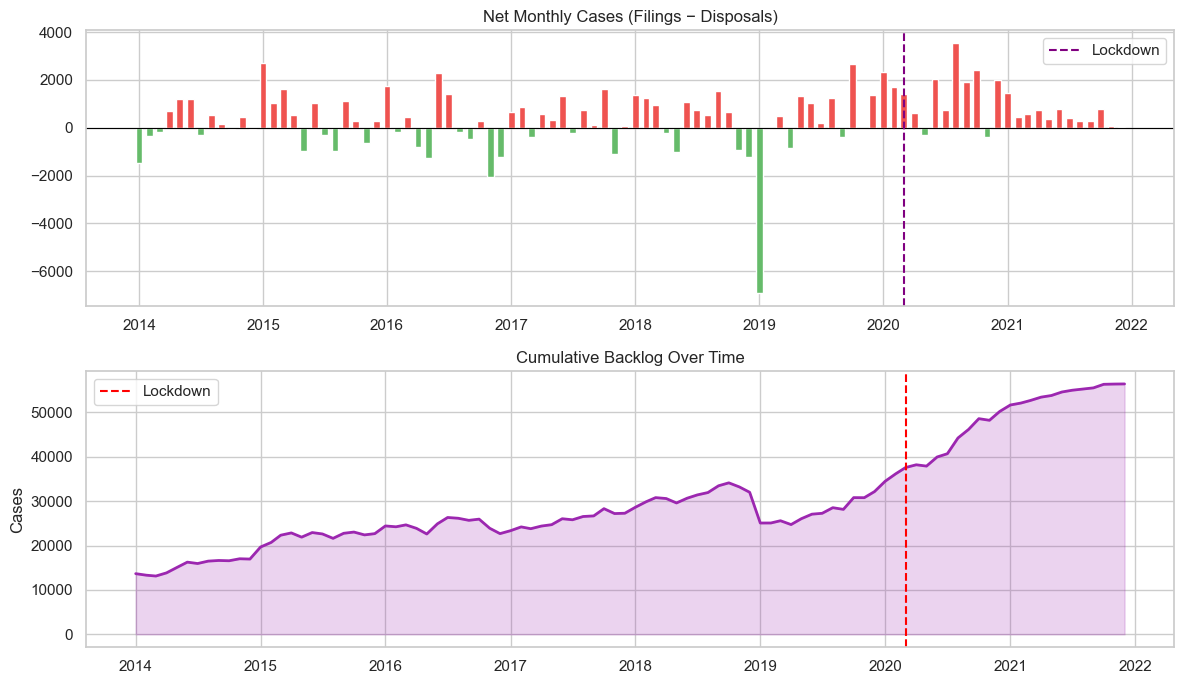

Peak cumulative backlog month: 2021-12-01 00:00:00
Peak backlog level: 56,408


In [7]:
# Align on common months
merged = pd.merge(
    monthly_filings.rename(columns={"filed_month": "month"}),
    monthly_disposals.rename(columns={"disposed_month": "month"}),
    on="month", how="outer"
).fillna(0).sort_values("month")

merged["net_monthly"]  = merged["filings"] - merged["disposals"]

# Compute true cumulative backlog at the end of each month
backlogs = []
for m in merged["month"]:
    m_end = m + pd.offsets.MonthEnd(1)
    # A case is pending at m_end if it was filed on or before m_end 
    # AND (it is not yet disposed OR it was disposed after m_end)
    b = raw[(raw["DATE_FILED"] <= m_end) & 
            (raw["DECISION_DATE"].isna() | (raw["DECISION_DATE"] > m_end))].shape[0]
    backlogs.append(b)

merged["cum_backlog"] = backlogs

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].bar(merged["month"], merged["net_monthly"],
            color=["#EF5350" if v > 0 else "#66BB6A" for v in merged["net_monthly"]],
            width=20)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(LOCKDOWN_DATE, color="purple", linestyle="--", label="Lockdown")
axes[0].set_title("Net Monthly Cases (Filings − Disposals)")
axes[0].legend()

axes[1].plot(merged["month"], merged["cum_backlog"], color="#9C27B0", linewidth=2)
axes[1].fill_between(merged["month"], merged["cum_backlog"], alpha=0.2, color="#9C27B0")
axes[1].axvline(LOCKDOWN_DATE, color="red", linestyle="--", label="Lockdown")
axes[1].set_title("Cumulative Backlog Over Time")
axes[1].set_ylabel("Cases")
axes[1].legend()

plt.tight_layout()
plt.show()

peak_backlog_month = merged.loc[merged["cum_backlog"].idxmax(), "month"]
print(f"Peak cumulative backlog month: {peak_backlog_month}")
print(f"Peak backlog level: {merged['cum_backlog'].max():,.0f}")


## H. Court-Level COVID Recovery Comparison

,court,level_change,level_pval,slope_recovery,recovery_pval
0,ORISSA HIGH COURT,-657.658,0.059,34.927,0.485
1,RAJASTHAN,118.728,0.732,-73.687,0.001
2,JHARKHAND,-905.591,0.038,103.615,0.140
3,CALCUTTA HIGH COURT,-242.266,0.246,-4.394,0.703
4,KERALA,-226.597,0.001,35.034,0.011
5,GAUHATI HIGH COURT,-277.019,0.006,11.294,0.080


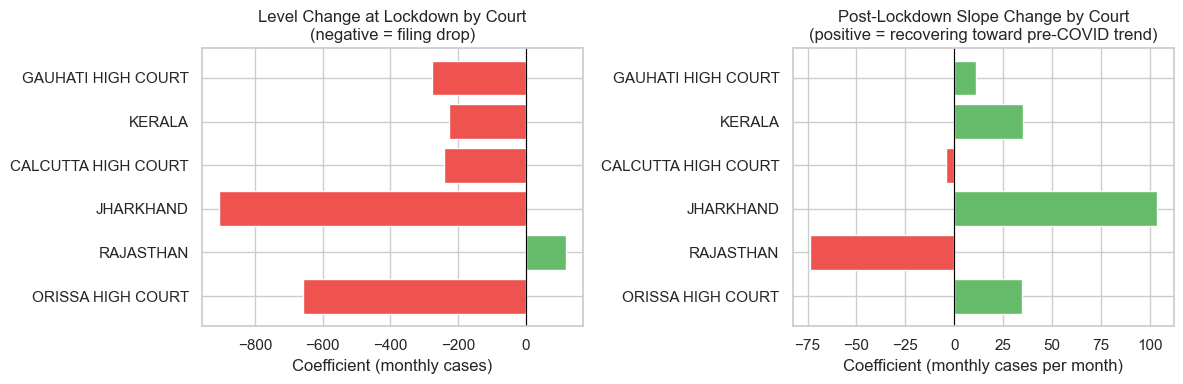

In [8]:
# For top 6 courts by volume: run ITS on filing volume and extract level-change coefficient
top_courts = raw["NAME_OF_HIGH_COURT"].value_counts().head(6).index.tolist()
court_its_results = []

for court in top_courts:
    court_data = (
        raw[raw["NAME_OF_HIGH_COURT"] == court]
           .dropna(subset=["filed_month"])
           .groupby("filed_month")
           .size()
           .rename("filings")
           .reset_index()
    )
    court_data["filed_month"] = court_data["filed_month"].dt.to_timestamp()
    court_data = court_data[
        (court_data["filed_month"] >= "2015-01-01") &
        (court_data["filed_month"] <= "2021-12-31")
    ].sort_values("filed_month")

    if len(court_data) < 30:
        continue

    its_c = build_its_df(court_data, "filed_month", "filings")
    X_c   = sm.add_constant(its_c[["t", "lockdown", "time_after"]])
    m_c   = sm.OLS(its_c["Y"], X_c).fit(cov_type="HAC", cov_kwds={"maxlags": 3})

    court_its_results.append({
        "court":         court.replace("HIGH COURT OF ", "").replace("THE ", "")[:20],
        "level_change":  m_c.params["lockdown"],
        "level_pval":    m_c.pvalues["lockdown"],
        "slope_recovery":m_c.params["time_after"],
        "recovery_pval": m_c.pvalues["time_after"],
    })

court_its_df = pd.DataFrame(court_its_results)
display(court_its_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(court_its_df["court"], court_its_df["level_change"],
             color=["#EF5350" if v < 0 else "#66BB6A" for v in court_its_df["level_change"]])
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Level Change at Lockdown by Court\n(negative = filing drop)")
axes[0].set_xlabel("Coefficient (monthly cases)")

axes[1].barh(court_its_df["court"], court_its_df["slope_recovery"],
             color=["#66BB6A" if v > 0 else "#EF5350" for v in court_its_df["slope_recovery"]])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Post-Lockdown Slope Change by Court\n(positive = recovering toward pre-COVID trend)")
axes[1].set_xlabel("Coefficient (monthly cases per month)")

plt.tight_layout()
plt.show()


# Key Findings

## Interrupted Time Series Setup

| Component | Value |
|---|---|
| Dataset coverage | 2010–2021 |
| Intervention period | COVID-19 lockdown phase (2020) |
| Unit of analysis | Monthly bail case filings/disposals |
| Methodology | Interrupted Time Series (ITS) Regression |

---

## Structural Break During COVID-19

| Observation | Finding |
|---|---|
| Immediate pandemic shock | Sharp decline in court activity during lockdown months |
| Filing trend | Significant fall in new bail filings post-intervention |
| Disposal trend | Stronger contraction in disposals than filings |
| Recovery pattern | Partial recovery observed after reopening phases |

- The interrupted time series model identified a clear structural disruption in High Court bail operations during the COVID-19 period.
- Monthly filings and disposals both declined substantially immediately after the intervention point, indicating severe judicial workflow disruption.

---

## Trend Analysis

| Trend Component | Observed Pattern |
|---|---|
| Pre-COVID trend | Relatively stable/increasing judicial activity |
| Immediate level change | Negative shock after lockdown onset |
| Post-COVID slope | Gradual recovery but incomplete normalization |
| Backlog implication | Disposal slowdown exceeded filing slowdown |

- Disposal capacity deteriorated more sharply than filing activity, implying accumulation of pending matters during the pandemic period.
- Post-lockdown recovery trends remained below pre-pandemic trajectories for several months, suggesting persistent operational constraints.

---

## Institutional Implications

| Area | Interpretation |
|---|---|
| Judicial functioning | COVID-19 caused measurable institutional interruption |
| Case pendency | Likely increased due to disposal slowdown |
| Administrative resilience | Courts showed gradual but uneven recovery |
| Digital transition impact | Virtual functioning mitigated but did not eliminate disruption |

- The analysis suggests that the pandemic acted as an exogenous institutional shock affecting judicial throughput across High Courts.
- Recovery patterns indicate adaptive institutional behaviour, but not a full restoration of pre-pandemic processing rates within the observed period.

---

# Limitations

| Limitation Area | Description |
|---|---|
| Causal interpretation | ITS identifies temporal disruption but cannot isolate all concurrent policy effects |
| Aggregated analysis | Monthly aggregation may hide court-specific heterogeneity |
| Data standardization | High Courts follow non-uniform reporting and administrative practices |
| Pandemic complexity | Lockdowns, virtual hearings, and local restrictions varied across states |
| Measurement constraints | Administrative filings/disposals may not fully capture judicial productivity |
